In [127]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from category_encoders import TargetEncoder

import re 


# VER LOS QUE DATOS TIENE EL DATASET Y DE QUE TIPO SON 

In [128]:
df=pd.read_csv('/kaggle/input/datasets/fjcob1/idealista-madrid/Datos.csv')

In [129]:
df.shape

(11826, 14)

In [130]:
df.head()

,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
0,madrid,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,0,69,2.0,S,EXTERIOR,5ª,1,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,https://www.idealista.com/inmueble/106956987/
1,madrid,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,159000,91,3.0,N,EXTERIOR,1ª,0,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,https://www.idealista.com/inmueble/106906044/
2,madrid,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,0,36,1.0,S,NaN,2ª,0,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,https://www.idealista.com/inmueble/107306175/
3,madrid,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,0,58,1.0,S,INTERIOR,BAJO,0,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",https://www.idealista.com/inmueble/106325171/
4,madrid,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,750000,140,3.0,S,EXTERIOR,2ª,0,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",https://www.idealista.com/inmueble/106627265/


In [131]:
df.columns

Index(['provincia', 'zona', 'titulo', 'PrecioActual', 'PrecioAnterior',
       'metros', 'habitaciones', 'ascensor', 'localizacion', 'planta', 'baños',
       'tags', 'descripcion', 'Enlace'],
      dtype='object')

In [132]:
df.dtypes


provincia          object
zona               object
titulo             object
PrecioActual        int64
PrecioAnterior      int64
metros              int64
habitaciones      float64
ascensor           object
localizacion       object
planta             object
baños               int64
tags               object
descripcion        object
Enlace             object
dtype: object

In [133]:
df.describe()



,PrecioActual,PrecioAnterior,metros,habitaciones,baños
count,1.182600e+04,1.182600e+04,11826.000000,11460.000000,11826.000000
mean,1.030501e+06,7.359704e+04,153.790039,2.847731,0.394047
std,1.237718e+06,3.639753e+05,766.217750,1.432402,0.882134
min,1.200000e+04,0.000000e+00,11.000000,1.000000,0.000000
25%,2.890000e+05,0.000000e+00,68.000000,2.000000,0.000000
50%,6.200000e+05,0.000000e+00,103.000000,3.000000,0.000000
75%,1.329000e+06,0.000000e+00,160.000000,3.000000,0.000000
max,2.300000e+07,8.450000e+06,75000.000000,20.000000,7.000000


**PrecioActual**

   *  La media es de 1.030.501 €. Pero la mediana (el valor del 50 %) es de 620.000 €, lo que indica que la media está muy inflada por pisos extremadamente caros.

   *  El piso más barato es de 12.000 € y el más caro de 230.000.000 €.
    
**PrecioAnterior**

   * Los porcentajes (25 %, 50 % y 75 %) marcan 0. Esto significa que al menos el 75 % de los anuncios no tienen un precio anterior.
    
**Metros**
    
   *  El valor máximo es de 75.000 m², lo que probablemente sea un error o corresponda a un solar.

   *  La mediana (50 %) es de 103 m², un tamaño lógico.

   *  El tamaño mínimo es de 11 m².

**Baños**

   *  Raro que en los porcentajes aparezca 0. Seguramente, en la mayoría de los anuncios no se rellenó ese dato o se guardó como 0.

**Habitaciones**

   *  Faltan datos. Tenemos 11.460 frente 11.826 pisos totales. Es decir, hay 366 pisos que tienen valor nulo (NaN)
    
   *  El piso con más habitaciones tiene 20 (podria ser un edificio entero / palacio)




In [134]:
df.select_dtypes(include='number').dtypes

PrecioActual        int64
PrecioAnterior      int64
metros              int64
habitaciones      float64
baños               int64
dtype: object

In [135]:
df.select_dtypes(include='object').dtypes

provincia       object
zona            object
titulo          object
ascensor        object
localizacion    object
planta          object
tags            object
descripcion     object
Enlace          object
dtype: object

# BUSCAR CORRELACION ENTRE **VARIABLE NUMERICAS**  CON VARIABLE OBJETIVO (PrecioActual)


In [136]:
df.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').sort_values(ascending=False)

habitaciones      0.504158
metros            0.130661
PrecioAnterior    0.120442
baños             0.048852
Name: PrecioActual, dtype: float64

1. VER CUANTOS PISOS TIENEN METROS ANOMALOS

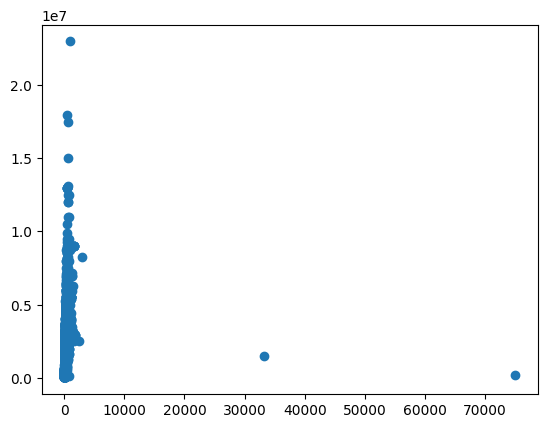

In [137]:
plt.scatter(data=df, x='metros', y='PrecioActual')

Text(0.5, 1.0, 'Metros vs Precio Actual')

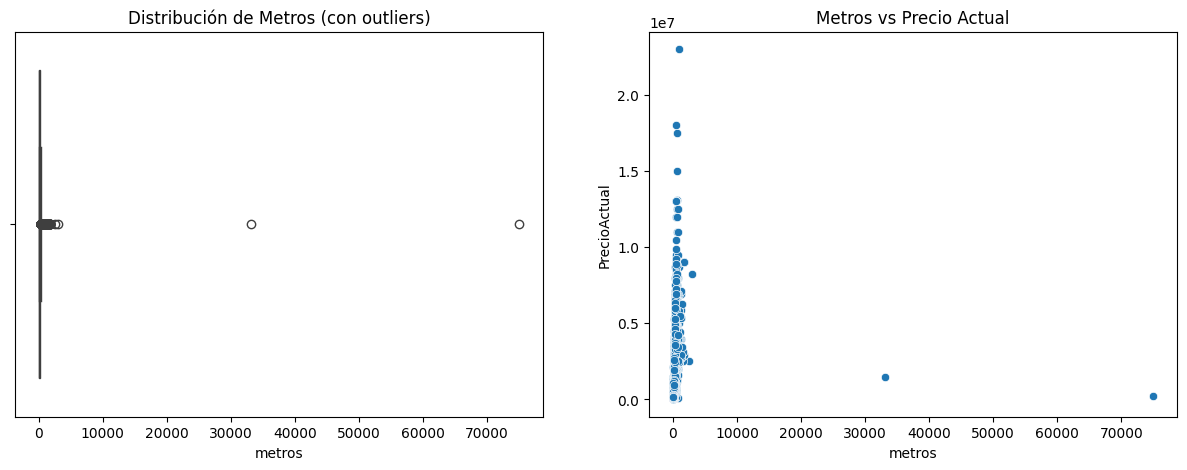

In [138]:
#Una figura con dos graficos dentro 
fig, axes = plt.subplots(1,2, figsize=(15,5))

#crar graf blox | x=m2 | en el grafico izquierda
sns.boxplot(x=df['metros'], ax=axes[0])
axes[0].set_title('Distribución de Metros (con outliers)')

#grafico derecha
sns.scatterplot(data=df, x='metros', y='PrecioActual', ax=axes[1], alpha=1.0)
axes[1].set_title('Metros vs Precio Actual')



In [139]:
df.query('metros>30000')
#6979,7997

,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
6979,madrid,ciudad-lineal,"Piso en calle de Emilio Ferrari, s/n, Pueblo N...",192000,0,75000,3.0,N,EXTERIOR,1ª,0,"VIVIENDA,INMOBILIARIA",VIVIENDA OCUPADASe admiten ofertas***SIN COMIS...,https://www.idealista.com/inmueble/107196960/
7997,madrid,hortaleza,"Chalet adosado en Palomas, Madrid",1495000,0,33175,7.0,NaN,NaN,NaN,0,"AMPLIO,EXCLUSIVA,OPORTUNIDAD,CHALET,REFORMAR,M...",Este fantástico pareado se encuentra en Piover...,https://www.idealista.com/inmueble/106105382/


In [140]:
df.query('PrecioActual>20000000')
#6489


,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
6489,madrid,chamartin,Casa o chalet independiente en calle de Castel...,23000000,0,1000,7.0,NaN,NaN,NaN,0,CASA,Lucía Suárez-Zuloaga de GV | EL VISO comercial...,https://www.idealista.com/inmueble/107095805/


In [141]:
df.shape

(11826, 14)

* 2. Realizar **IQR** para ver cuanto ocupa el 50% central de los datos
    
      

In [142]:
# --- TU VERSIÓN: FILTRO POR METROS (MANUAL/EXTREMO) ---
Q1_m = df['metros'].quantile(0.25)
Q3_m = df['metros'].quantile(0.75)
IQR_m = Q3_m - Q1_m

limite_inferior_m = 15 # Valor fijo puesto por ti
limite_superior_m = Q3_m + 3.0 * IQR_m # Factor 3.0 (Extremo)

df_limpio = df[(df['metros'] >= limite_inferior_m) & (df['metros'] <= limite_superior_m)].copy()

print(f"Tu filtro de metros: de {limite_inferior_m} a {limite_superior_m:.2f} m2")

Tu filtro de metros: de 15 a 436.00 m2


* 3 Ver como ha quedado el grafico después de la limpieza


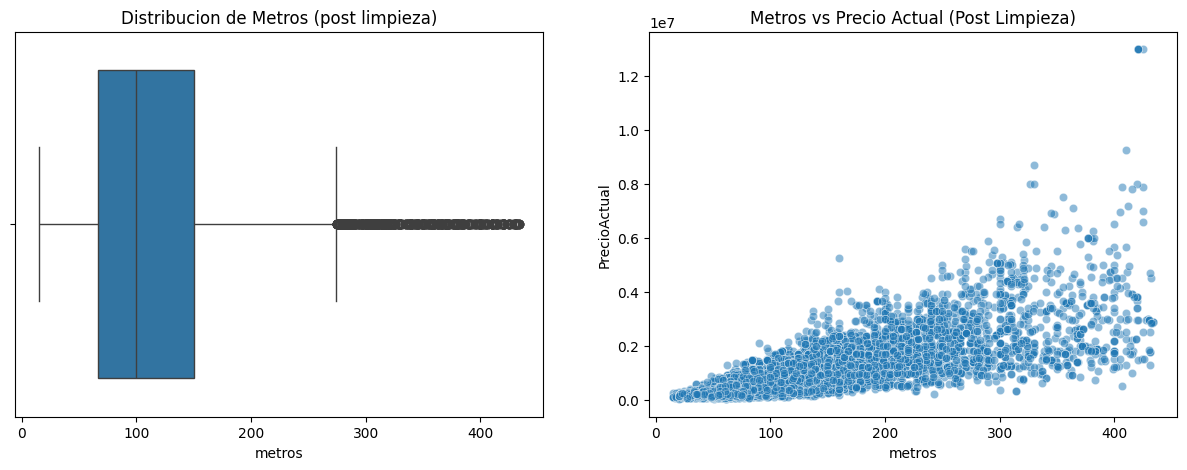

In [143]:
# Cambiamos 'fix' por 'fig'
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=df_limpio['metros'], ax=axes[0])
axes[0].set_title('Distribucion de Metros (post limpieza)')

sns.scatterplot(data=df_limpio, x='metros', y='PrecioActual', ax=axes[1], alpha=0.5)
axes[1].set_title('Metros vs Precio Actual (Post Limpieza)')

plt.show()

In [144]:
 df_limpio.shape


(11351, 14)

In [145]:
df_limpio.query('metros > 400 & metros < 500 & PrecioActual > 1200000') \
          .sort_values(by='PrecioActual', ascending=False)

,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
7614,madrid,barrio-de-salamanca,"Piso en Recoletos, Madrid",13000000,0,421,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,PISO,EXCLUSIVA,LUJO,ESPECTACULAR,FINC...",Presentamos esta espectacular y exclusiva vivi...,https://www.idealista.com/inmueble/107165396/
6546,madrid,barrio-de-salamanca,"Piso en calle Velázquez, Recoletos, Madrid",13000000,0,425,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,INMOBILIARIA","Álvora Capital Properties, consultora inmobili...",https://www.idealista.com/inmueble/107166409/
9675,madrid,barrio-de-salamanca,"Piso en Recoletos, Madrid",13000000,0,421,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,PISO,REFORMADO,EXCLUSIVA,LUJO,ESPECTA...",Olisson Club pone a su disposición esta espect...,https://www.idealista.com/inmueble/106771279/
7522,madrid,barrio-de-salamanca,"Piso en calle Velázquez, Recoletos, Madrid",13000000,0,421,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,PISO,LUJO,ESPECTACULAR,EXCLUSIVO,INMO...",REA Inmobiliaria presenta este exclusivo piso ...,https://www.idealista.com/inmueble/107212046/
6191,madrid,barrio-de-salamanca,"Piso en calle de Velázquez, Recoletos, Madrid",13000000,0,421,5.0,S,EXTERIOR,3ª,0,"VIVIENDA,PISO,REFORMADO,LUJO,ELECTRODOMÉSTICOS...",Olivares Consultores vende esta vivienda de lu...,https://www.idealista.com/inmueble/106652699/
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4355,madrid,fuencarral,"Chalet pareado en Peñagrande, Madrid",1490000,0,424,5.0,NaN,NaN,NaN,0,"VIVIENDA,PAREADO",Laura Pérez-Hernandez de GV | PUERTA DE HIERRO...,https://www.idealista.com/inmueble/107191570/
5148,madrid,moncloa,"Ático en Valdemarín, Madrid",1450000,0,421,5.0,S,EXTERIOR,4ª,0,"ÁTICO,EXCLUSIVA,PISCINA,DÚPLEX,URBANIZACIÓN,SE...",Lucas Fox se complace en presentar este fabulo...,https://www.idealista.com/inmueble/93282892/
312,madrid,moncloa,"Chalet pareado en El Plantío, Madrid",1300000,0,410,6.0,NaN,NaN,NaN,0,"VIVIENDA,PARCELA",Vivienda situada en la zona de El Plantío.La v...,https://www.idealista.com/inmueble/107008438/
8185,madrid,san-blas,"Piso en Simancas, Madrid",1300000,0,431,5.0,S,EXTERIOR,4ª,0,"TERRAZA,OPORTUNIDAD,PARQUE",Coldwell Banker presenta este amplísimo espaci...,https://www.idealista.com/inmueble/107013062/


In [146]:
# Para ver los precios normales y no como 1.22e+06
pd.options.display.float_format = '{:,.2f}'.format

# Vamos a ver el Top 5 de los más caros para entender el nivel de lujo
print(df_limpio.sort_values('PrecioActual', ascending=False).head(5))

     provincia                 zona  \
7614    madrid  barrio-de-salamanca   
6191    madrid  barrio-de-salamanca   
7522    madrid  barrio-de-salamanca   
9675    madrid  barrio-de-salamanca   
6546    madrid  barrio-de-salamanca   

                                             titulo  PrecioActual  \
7614                      Piso en Recoletos, Madrid      13000000   
6191  Piso en calle de Velázquez, Recoletos, Madrid      13000000   
7522     Piso en calle Velázquez, Recoletos, Madrid      13000000   
9675                      Piso en Recoletos, Madrid      13000000   
6546     Piso en calle Velázquez, Recoletos, Madrid      13000000   

      PrecioAnterior  metros  habitaciones ascensor localizacion planta  \
7614               0     421          5.00        S     EXTERIOR     3ª   
6191               0     421          5.00        S     EXTERIOR     3ª   
7522               0     421          5.00        S     EXTERIOR     3ª   
9675               0     421          5.00        

# VARIABLE DE LUJO

In [147]:
#import numpy as np

# 1. Nos aseguramos de que el DataFrame sea independiente para que Pandas no se queje
#df_limpio = df_limpio.copy()

# 2. Creamos la columna usando np.where (Si precio > 2M, pon 1, si no, pon 0)
#df_limpio['piso_lujo'] = np.where(df_limpio['PrecioActual'] > 2000000, 1, 0)

# 3. Comprobamos que se ha creado correctamente
#print("¡Columna creada con éxito!")
#print(df_limpio[['PrecioActual', 'piso_lujo']].head(10))

In [148]:
# OPCIÓN 1: Ver el recuento de ambos (Normales y Lujo)
#print("--- RECUENTO TOTAL ---")
#print(df_limpio['piso_lujo'].value_counts())

# OPCIÓN 2: Extraer exactamente el número de pisos de lujo (los "1")
#total_lujo = df_limpio['piso_lujo'].sum()
#print(f"\n¡Tienes exactamente {total_lujo} pisos de lujo (más de 2 millones) en tu dataset!")

In [149]:
#import numpy as np

# 1. Nos aseguramos de que el DataFrame sea independiente para que Pandas no se queje
#df_limpio = df_limpio.copy()

# 2. Creamos la columna usando np.where (Si precio > 2M, pon 1, si no, pon 0)
#df_limpio['piso_lujo'] = np.where(df_limpio['PrecioActual'] > 2000000, 1, 0)

# 3. Comprobamos que se ha creado correctamente
#print("¡Columna creada con éxito!")
#print(df_limpio[['PrecioActual', 'piso_lujo']].head(80))

In [150]:
#viendo el codigo de arriba me doy cuenta de que duplicados, decidor eliminarlos 
#df_limpio = df_limpio.drop_duplicates(subset=['titulo', 'PrecioActual', 'metros'])

In [151]:
df.shape

(11826, 14)

3. Sacar la correlacin para ver como cambio en relacion a la anterior que estaba con outiers 

In [152]:
df_limpio.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').sort_values(ascending=False)

metros           0.79
habitaciones     0.43
PrecioAnterior   0.13
baños            0.09
Name: PrecioActual, dtype: float64

**2. VER HABITACIONES**

Cuando se hizo el *describe*, habia  361 valores nulos (NaN) y un valor máximo de 20 habitaciones que suena a otro error (o es un hotel) 


Text(0.5, 1.0, 'Relación entre habitaciones y precio')

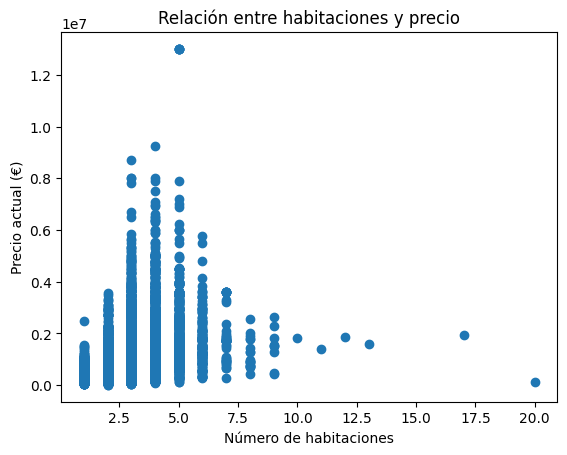

In [153]:
plt.scatter(x='habitaciones', y='PrecioActual', alpha=1.0, data=df_limpio) 

plt.xlabel('Número de habitaciones')   # eje X
plt.ylabel('Precio actual (€)')        # eje Y
plt.title('Relación entre habitaciones y precio')

In [154]:
#AL HACER UN df_limpio.query() me di cuenta de que  HABIA PISOS IGUALES 

# 1. Definimos las columnas que "delatan" al mismo piso
columnas_clave = ['PrecioActual', 'zona', 'planta', 'habitaciones']

# 2. Eliminamos los duplicados basándonos en esas claves
# 'keep=first' significa que nos quedamos con el primer anuncio que encuentre
df_limpio = df_limpio.drop_duplicates(subset=columnas_clave, keep='first').copy()


1. HACEMOS UNA LIMPIEZA DE OUTLINERS

    Nos quedamos solo con viviendas de entre 1 y 10 habitaciones
    (Eliminamos el error de 20 y posibles locales de 0)

    Rellenamos los huecos vacíos (NaN) con la median

In [155]:

df_limpio.query('habitaciones >= 10')

df_limpio = df_limpio[df_limpio['habitaciones'] < 10].copy()

In [156]:
df_limpio.drop(index=6191, inplace=True)

Text(0.5, 1.0, 'Relación entre habitaciones y precio PostLimpieza')

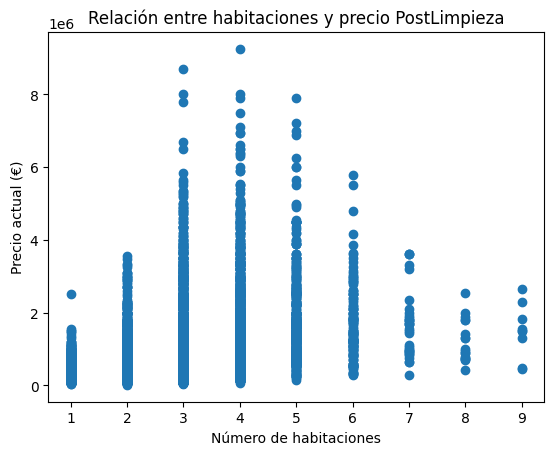

In [157]:
plt.scatter(x='habitaciones', y='PrecioActual', alpha=1.0, data=df_limpio) 

plt.xlabel('Número de habitaciones')   # eje X
plt.ylabel('Precio actual (€)')        # eje Y
plt.title('Relación entre habitaciones y precio PostLimpieza')


In [158]:

df_limpio['habitaciones'] = df['habitaciones'].fillna(df['habitaciones'].median())

In [159]:
df_limpio.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').sort_values(ascending=False)

metros           0.80
habitaciones     0.43
PrecioAnterior   0.14
baños            0.08
Name: PrecioActual, dtype: float64

In [160]:
 df_limpio.shape

(8612, 14)

# no se si tendre que arreglar habitaciones tiene una CORRELACION 0.4

2. **BAÑOS**
   
* Esta variable genera dudas, ya que el análisis con describe() indica que casi todo el dataset tiene valor 0, lo cual resulta poco realista.
* Teniendo en cuenta esto, no estaba claro si eliminar la columna (drop) o intentar corregirla de alguna forma.

Text(0, 0.5, 'Precio (millones)')

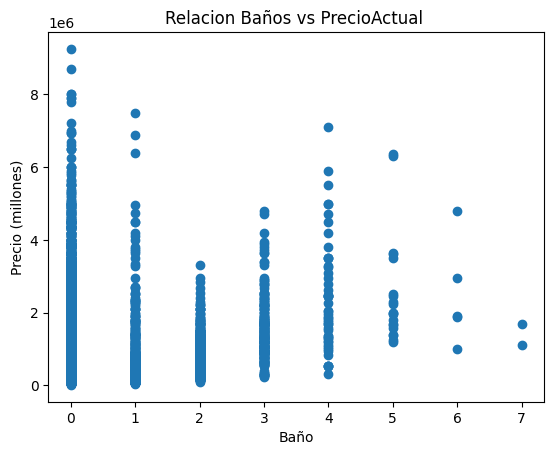

In [161]:
plt.scatter(data=df_limpio, x='baños', y='PrecioActual')
plt.title('Relacion Baños vs PrecioActual ')
plt.xlabel('Baño')
plt.ylabel('Precio (millones)')

**2.1.Intento de Arreglo**

In [162]:
# 1. Todo lo que sea 0 baños, pasa a ser 1 (mínimo habitable)
df_limpio.loc[df_limpio['baños'] == 0, 'baños'] = 1

# 2. Si el piso es grande (>110 m2) y tiene 1 baño, le ponemos 2
df_limpio.loc[(df_limpio['baños'] == 1) & (df_limpio['metros'] > 110), 'baños'] = 2

# 3. Si el piso es muy grande (>200 m2) y tiene 1 o 2, le ponemos 3
df_limpio.loc[(df_limpio['baños'] < 3) & (df_limpio['metros'] > 200), 'baños'] = 3

# 4. Calculamos la nueva correlación
print("Nueva tabla de correlaciones:")
df_limpio.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').sort_values(ascending=False)

Nueva tabla de correlaciones:


metros           0.80
baños            0.70
habitaciones     0.43
PrecioAnterior   0.14
Name: PrecioActual, dtype: float64

Text(0, 0.5, 'Precio (millones)')

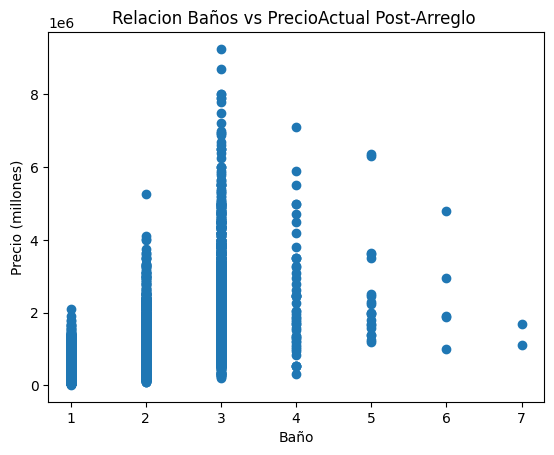

In [163]:
plt.scatter(data=df_limpio, x='baños', y='PrecioActual')
plt.title('Relacion Baños vs PrecioActual Post-Arreglo ')
plt.xlabel('Baño')
plt.ylabel('Precio (millones)')

In [164]:
df_limpio.shape

(8612, 14)

3. **PrecioAnterior**

intento de arreglar precio Atnerior creando varibale tiene_rebaja 

In [165]:
# Creamos una columna: 1 si tiene precio anterior (hubo rebaja), 0 si no.
#df_limpio['tiene_rebaja'] = (df_limpio['PrecioAnterior'] > 0).astype(int)

# Miramos si "tener rebaja" ayuda a predecir el precio actual
#print("Correlación de 'tiene_rebaja':")
#print(df_limpio['tiene_rebaja'].corr(df_limpio['PrecioActual']))

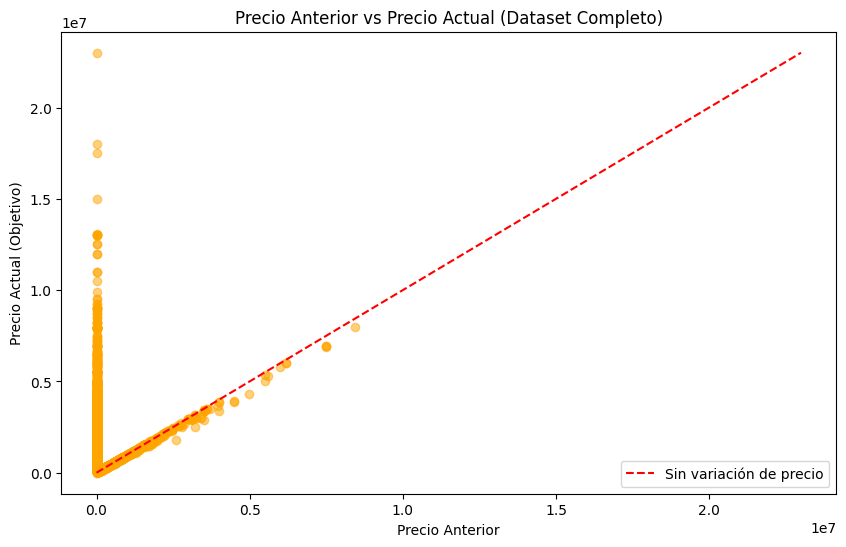

In [166]:
# Crear la figura con un buen tamaño
plt.figure(figsize=(10, 6))

# Dibujar todos los datos sin filtrar (alpha=0.5 añade transparencia)
plt.scatter(x=df['PrecioAnterior'], y=df['PrecioActual'], alpha=0.5, color='orange')

# Trazar una línea roja diagonal de referencia (PrecioAnterior == PrecioActual)
max_val = max(df['PrecioAnterior'].max(), df['PrecioActual'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Sin variación de precio')

# Títulos y etiquetas
plt.xlabel('Precio Anterior')
plt.ylabel('Precio Actual (Objetivo)')
plt.title('Precio Anterior vs Precio Actual (Dataset Completo)')
plt.legend()

# Mostrar la gráfica
plt.show()

el 95% de los pisos, el PrecioAnterior es exactamente igual al PrecioActual (porque nunca han bajado de precio). i metes PrecioAnterior como una variable más (X) para que tu modelo adivine el PrecioActual (Y), el modelo se volverá "vago". Se dará cuenta de que la forma más fácil de acertar es simplemente copiar el valor de PrecioAnterior

**3.eliminar pisos con precio 0 o null o nan y volver a ver la correlacion**

In [167]:
#print(f"Filas antes de limpiar: {len(df)}")

# Nos aseguramos de que ambas columnas sean tratadas como números.
# Si hay algún texto raro o vacío, se convertirá en NaN automáticamente.
#df_limpio['PrecioActual'] = pd.to_numeric(df['PrecioActual'], errors='coerce')
#df_limpio['PrecioAnterior'] = pd.to_numeric(df['PrecioAnterior'], errors='coerce')

# Eliminamos cualquier fila que tenga un NaN en alguna de estas dos columnas
#df_limpio = df_limpio.dropna(subset=['PrecioActual', 'PrecioAnterior'])

# Nos quedamos estrictamente con los pisos que cuesten más de 0€
# (esto elimina los 0 y también posibles precios negativos si hubiera errores)
#df_limpio = df_limpio[(df_limpio['PrecioActual'] > 0) & (df_limpio['PrecioAnterior'] > 0)]

#print(f"Filas después de limpiar: {len(df_limpio)}")
#print("-" * 50)

In [168]:
# 1. Creamos la columna de descuento porcentual
# Si no hay PrecioAnterior, el descuento es 0
#df_limpio['pct_descuento'] = (df_limpio['PrecioAnterior'] - df_limpio['PrecioActual']) / df_limpio['PrecioAnterior']

# 2. Los que no tenían precio anterior (NaN o Infinito por dividir por 0) los ponemos a 0
#df_limpio['pct_descuento'] = df_limpio['pct_descuento'].fillna(0)
# En caso de que PrecioAnterior fuera 0, la división da inf, corregimos:
#import numpy as np
#df_limpio['pct_descuento'] = df_limpio['pct_descuento'].replace([np.inf, -np.inf], 0)

# 3. Limpiamos posibles errores (descuentos negativos o > 100%)
#df_limpio.loc[df_limpio['pct_descuento'] < 0, 'pct_descuento'] = 0

# Borrar Columna PrecioAnterior

Al realizar los dos bloque de arriba me daba una correlacion muy mala. Debido a que la columna PrecioActual tiene muhcos valores 0 y valores NaN, lo mejor es no usarla para el modelo de IA

In [169]:
# Borra la columna solo si existe. Si ya se borró, ignora el comando y no da error.
df_limpio = df_limpio.drop(columns=['PrecioAnterior'], errors='ignore')

# Comprobamos las columnas que han sobrevivido
print("Columnas actuales listas para el modelo:")
print(list(df_limpio.columns))

Columnas actuales listas para el modelo:
['provincia', 'zona', 'titulo', 'PrecioActual', 'metros', 'habitaciones', 'ascensor', 'localizacion', 'planta', 'baños', 'tags', 'descripcion', 'Enlace']


In [170]:
df_limpio.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').sort_values(ascending=False)

metros         0.80
baños          0.70
habitaciones   0.43
Name: PrecioActual, dtype: float64

In [171]:
df_limpio.shape

(8612, 13)

# BUSCAR CORRELACION ENTRE VARIABLE **ZONA** CON VARIABLE OBJETIVO (PrecioActual) --> FUMATIDA DE SERGIO


1. **Zona**

   Codificamos las zonas para saber el verdadero peso que tendra en el modelo

In [172]:
from category_encoders import TargetEncoder

# Asegurar que el target es numérico
df_limpio["PrecioActual"] = pd.to_numeric(df_limpio["PrecioActual"], errors="coerce")

# Inicializar el encoder
encoder = TargetEncoder(cols=['zona'])

# Aplicar el encoding y crear la columna en df_limpio
df_limpio['zona_codificada'] = encoder.fit_transform(df_limpio['zona'], df_limpio['PrecioActual'])

In [173]:
print(df_limpio.select_dtypes(include='number').corr()['PrecioActual'].drop('PrecioActual').abs().sort_values(ascending=False))

metros            0.80
baños             0.70
zona_codificada   0.58
habitaciones      0.43
Name: PrecioActual, dtype: float64


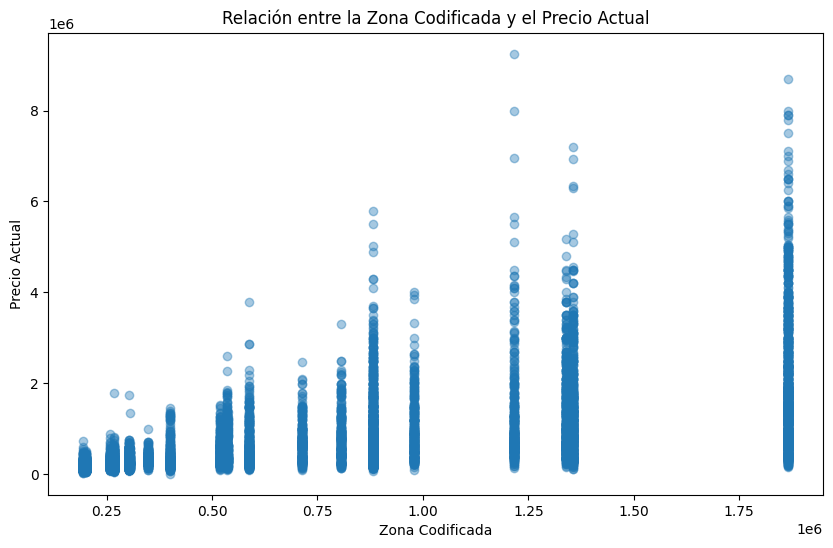

In [174]:
plt.figure(figsize=(10, 6))

# Dibujamos los puntos con algo de transparencia (alpha=0.4) para ver dónde hay más pisos
plt.scatter(x='zona_codificada', y='PrecioActual', data=df_limpio, alpha=0.4)

plt.title('Relación entre la Zona Codificada y el Precio Actual')
plt.xlabel('Zona Codificada')
plt.ylabel('Precio Actual')
plt.show()

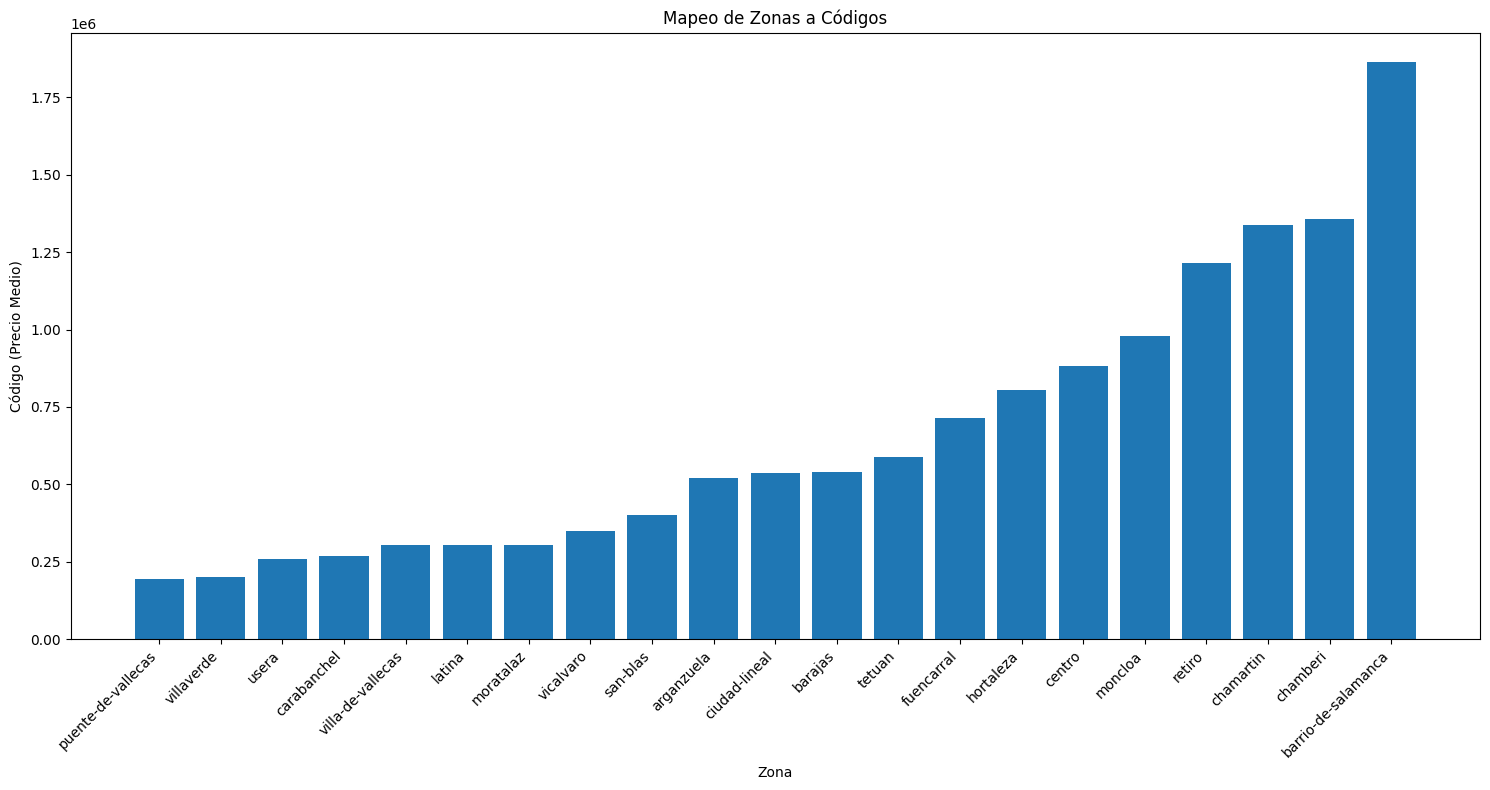

In [175]:
# 1. Extraemos los valores únicos de zona y su código, ordenados de menor a mayor
mapeo_completo = df_limpio[['zona', 'zona_codificada']].drop_duplicates().sort_values(by='zona_codificada')

# 2. Creamos un gráfico de barras
plt.figure(figsize=(15, 8))
plt.bar(mapeo_completo['zona'], mapeo_completo['zona_codificada'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Zona')
plt.ylabel('Código (Precio Medio)')
plt.title('Mapeo de Zonas a Códigos')
plt.tight_layout()
plt.show()

2. **Provincia**

Eliminanos esta columna porque no aporta nada


In [176]:
# Contamos cuántos pisos hay en cada provincia
conteo_provincias = df_limpio['provincia'].value_counts()

#print("Distribución de provincias en el dataset:")
print(conteo_provincias)

# Vemos cuántas provincias únicas hay
print(f"\nTotal de provincias distintas: {df_limpio['provincia'].nunique()}")

provincia
madrid    8612
Name: count, dtype: int64

Total de provincias distintas: 1


In [177]:
df_limpio = df_limpio.drop('provincia', axis=1)

3. **titulo**

In [178]:
df_limpio = df_limpio.drop('titulo', axis=1)

In [179]:
print(df_limpio.columns)

Index(['zona', 'PrecioActual', 'metros', 'habitaciones', 'ascensor',
       'localizacion', 'planta', 'baños', 'tags', 'descripcion', 'Enlace',
       'zona_codificada'],
      dtype='object')


4.**Ascensor**

In [180]:
# 1. Creamos los dummies. 
# dtype=int convierte los True/False automáticos en 1 y 0
dummies_ascensor = pd.get_dummies(df_limpio['ascensor'], prefix='ascensor', drop_first=True, dtype=int)

# 2. Unimos los dummies a nuestro dataset principal
df_limpio = pd.concat([df_limpio, dummies_ascensor], axis=1)

# 3. Borramos la columna original de texto
df_limpio = df_limpio.drop(columns=['ascensor'], errors='ignore')

# Vemos el resultado de las nuevas columnas creadas
print("Así quedan tus nuevas columnas dummy:")
print(dummies_ascensor.head())

Así quedan tus nuevas columnas dummy:
   ascensor_S
0           1
1           0
2           1
3           1
4           1


In [181]:
print(df_limpio.select_dtypes(include='number').corr()['PrecioActual'].sort_values(ascending=False))

PrecioActual      1.00
metros            0.80
baños             0.70
zona_codificada   0.58
habitaciones      0.43
ascensor_S        0.28
Name: PrecioActual, dtype: float64


5. **Localizacion** 

In [182]:
# 1. Creamos la nueva columna: 1 si es exterior, 0 si es interior o NaN
df_limpio['es_exterior'] = df_limpio['localizacion'].apply(
    lambda x: 1 if str(x).strip().upper() == 'EXTERIOR' else 0
)

# 2. Borramos la columna original de texto
df_limpio = df_limpio.drop(columns=['localizacion'], errors='ignore')

# 3. Vemos qué impacto tiene ser exterior en el precio
correlacion_exterior = df_limpio[['es_exterior', 'PrecioActual']].corr().iloc[0,1]
print(f"Correlación de ser EXTERIOR con el precio: {correlacion_exterior:.4f}")

# Comprobamos cómo ha quedado el conteo de 1s y 0s
print("\nDistribución de la nueva columna:")
print(df_limpio['es_exterior'].value_counts())

Correlación de ser EXTERIOR con el precio: 0.1370

Distribución de la nueva columna:
es_exterior
1    6953
0    1659
Name: count, dtype: int64


6. Planta

In [183]:
df_limpio['planta'].unique()

array(['5ª', '1ª', '2ª', 'BAJO', '3ª', '6ª', nan, '4ª', '16ª', '13ª',
       '9ª', '7ª', '10ª', '8ª', '11ª', '12ª', 'ENTREPLANTA', 'SÓTANO',
       '-1', '15ª', '17ª', '20ª', '14ª', '-2', '27ª', '22ª', '21ª', '18ª'],
      dtype=object)

Limpiando la columna 'planta' original...
¡Dibujando la gráfica!


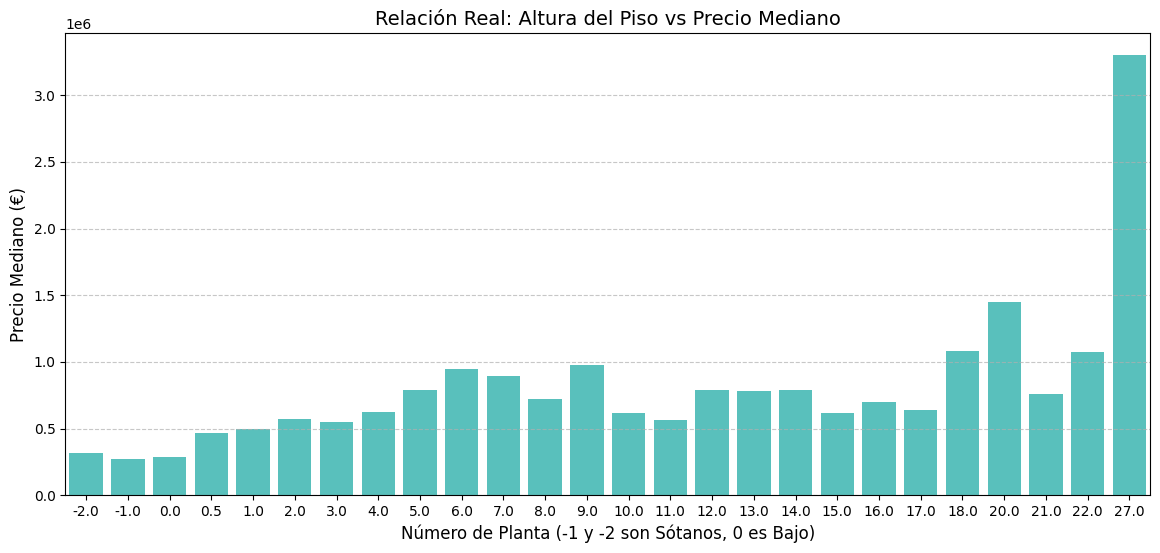

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. FUNCIÓN DE LIMPIEZA
def limpiar_planta(texto):
    texto = str(texto).upper().strip()
    if texto in ['NAN', 'NONE', 'NAN']: return None
    if 'SÓTANO' in texto: return -1
    if 'BAJO' in texto: return 0
    if 'ENTREPLANTA' in texto: return 0.5
    numeros = re.findall(r'-?\d+', texto)
    if numeros: return float(numeros[0])
    return None

# 2. COMPROBACIÓN Y CREACIÓN DE LA COLUMNA
if 'planta' in df_limpio.columns:
    print("Limpiando la columna 'planta' original...")
    df_limpio['planta_num'] = df_limpio['planta'].apply(limpiar_planta)
    df_limpio['planta_num'] = df_limpio['planta_num'].fillna(df_limpio['planta_num'].median())
    df_limpio = df_limpio.drop(columns=['planta']) # Borramos la vieja

# 3. GRÁFICA (Solo si la columna numérica existe)
if 'planta_num' in df_limpio.columns:
    print("¡Dibujando la gráfica!")
    plt.figure(figsize=(14, 6))

    sns.barplot(
        data=df_limpio, 
        x='planta_num', 
        y='PrecioActual', 
        estimator=np.median,
        color='mediumturquoise',
        errorbar=None
    )

    plt.title('Relación Real: Altura del Piso vs Precio Mediano', fontsize=14)
    plt.xlabel('Número de Planta (-1 y -2 son Sótanos, 0 es Bajo)', fontsize=12)
    plt.ylabel('Precio Mediano (€)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("❌ ALERTA: No encuentro ni 'planta' ni 'planta_num' en tus datos.")
    print(f"Tus columnas actuales son: {list(df_limpio.columns)}")

In [185]:
print(df_limpio.select_dtypes(include='number').corr()['PrecioActual'].sort_values(ascending=False))

PrecioActual      1.00
metros            0.80
baños             0.70
zona_codificada   0.58
habitaciones      0.43
ascensor_S        0.28
planta_num        0.21
es_exterior       0.14
Name: PrecioActual, dtype: float64


7. **TAGS** y **DESCRIPCION*

In [186]:
# 1. Unimos las etiquetas y la descripción en un solo texto gigante (en minúsculas)
texto_total = df_limpio['tags'].fillna('') + ' ' + df_limpio['descripcion'].fillna('')
texto_total = texto_total.str.lower()

# 2. Cazamos las palabras clave (1 si la palabra está en el texto, 0 si no)
# He puesto las más típicas, pero puedes añadir las que quieras
df_limpio['extra_piscina'] = texto_total.str.contains('piscina').astype(int)
df_limpio['extra_terraza'] = texto_total.str.contains('terraza').astype(int)
df_limpio['extra_garaje'] = texto_total.str.contains('garaje|parking|aparcamiento').astype(int)
df_limpio['extra_reformado'] = texto_total.str.contains('reformado|nuevo').astype(int)

# 3. Borramos las columnas de texto originales, que ya nos sobran
df_limpio = df_limpio.drop(columns=['tags', 'descripcion'], errors='ignore')

# 4. Vemos si alguna de estas palabras tiene impacto en el precio
print("Correlación de los nuevos extras con el precio:")
print(df_limpio[['extra_piscina', 'extra_terraza', 'extra_garaje', 'extra_reformado', 'PrecioActual']].corr()['PrecioActual'].sort_values(ascending=False))

Correlación de los nuevos extras con el precio:
PrecioActual       1.00
extra_terraza      0.02
extra_garaje       0.01
extra_piscina     -0.00
extra_reformado   -0.02
Name: PrecioActual, dtype: float64


 

    

         

            

     

Enlace          

In [187]:
df_limpio=df_limpio.drop(columns=['Enlace'])

In [188]:
print(df_limpio.columns)

Index(['zona', 'PrecioActual', 'metros', 'habitaciones', 'baños',
       'zona_codificada', 'ascensor_S', 'es_exterior', 'planta_num',
       'extra_piscina', 'extra_terraza', 'extra_garaje', 'extra_reformado'],
      dtype='object')


In [189]:
print(df_limpio.select_dtypes(include='number').corr()['PrecioActual'].sort_values(ascending=False))


PrecioActual       1.00
metros             0.80
baños              0.70
zona_codificada    0.58
habitaciones       0.43
ascensor_S         0.28
planta_num         0.21
es_exterior        0.14
extra_terraza      0.02
extra_garaje       0.01
extra_piscina     -0.00
extra_reformado   -0.02
Name: PrecioActual, dtype: float64


# CREAR DOS VARIABLES NUEVAS

metros por habitacion y ratio_banios

In [190]:
# 1. Creamos la variable de 'Amplitud' (Metros cuadrados por estancia)
# Nos dice cuánto espacio real hay por cada habitación.
df_limpio['metros_por_hab'] = df_limpio['metros'] / (df_limpio['habitaciones'] + 1)

# 2. Creamos el 'Índice de Privacidad/Confort' (Baños por habitación)
# Un valor alto (ej: 0.8) indica que casi cada habitación tiene su propio baño. 
# Un valor bajo (ej: 0.2) indica que mucha gente comparte el mismo baño.
df_limpio['ratio_banos'] = df_limpio['baños'] / (df_limpio['habitaciones'] + 1)

# Echamos un vistazo para ver cómo han quedado
print("--- NUEVAS VARIABLES DE CONFORT ---")
print(df_limpio[['metros', 'habitaciones', 'metros_por_hab', 'baños', 'ratio_banos']].head())

--- NUEVAS VARIABLES DE CONFORT ---
   metros  habitaciones  metros_por_hab  baños  ratio_banos
0      69          2.00           23.00      1         0.33
1      91          3.00           22.75      1         0.25
2      36          1.00           18.00      1         0.50
3      58          1.00           29.00      1         0.50
4     140          3.00           35.00      2         0.50


# FUMADITA DE SERGIO II



In [191]:
# --- BLOQUE 1: NUEVAS VARIABLES (INGENIERÍA DE FEATURES) ---

# 1. Interacciones clave (Zona x Tamaño)

#df_limpio['zona_metros'] = df_limpio['zona_codificada'] * df_limpio['metros']
#df_limpio['zona_planta'] = df_limpio['zona_codificada'] * df_limpio['planta_num']

# 2. Relaciones no lineales (Logaritmos para que la IA entienda mejor los tamaños)
#df_limpio['log_metros'] = np.log1p(df_limpio['metros'])

# 3. Ratios de confort (Lo que ya teníamos, pero refinado)
#df_limpio['metros_por_habitacion'] = df_limpio['metros'] / (df_limpio['habitaciones'] + 0.1)
#df_limpio['banos_por_habitacion'] = df_limpio['baños'] / (df_limpio['habitaciones'] + 0.1)

# 4. Score de Calidad (Suma todos los 'extra_')
# Esto crea una nota del 0 al 5 según cuántos lujos tenga el piso
#extras_cols = [col for col in df_limpio.columns if 'extra_' in col or col == 'ascensor_S']
#df_limpio['lujo_score'] = df_limpio[extras_cols].sum(axis=1)

#print("✅ Variables avanzadas creadas.")

In [192]:
# --- BLOQUE 3: SELECCIÓN DE VARIABLES PARA LA IA ---

# Definimos exactamente qué va a mirar el modelo
#columnas_finales = [
    #'metros', 'zona_codificada', 'zona_metros', 'log_metros',
    #'metros_por_habitacion', 'banos_por_habitacion', 'lujo_score',
    #'planta_num', 'zona_planta', 'es_exterior', 'habitaciones', 'baños'
#]

#X = df_limpio[columnas_finales]
#y = df_limpio['PrecioActual']

# Dividimos para el examen
#from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#print("✅ Datos listos para entrar al MODELO IA.")

In [193]:
# --- BLOQUE 2: LIMPIEZA DE OUTLIERS DE PRECIO ---

# Calculamos el IQR sobre el precio
#Q1_p = df_limpio['PrecioActual'].quantile(0.25)
#Q3_p = df_limpio['PrecioActual'].quantile(0.75)
#IQR_p = Q3_p - Q1_p

# Aplicamos el filtro con factor 2.0 (ni muy blando ni muy agresivo)
#limite_inf_p = Q1_p - 1.5 * IQR_p
#limite_sup_p = Q3_p + 2.0 * IQR_p

#df_limpio = df_limpio[(df_limpio['PrecioActual'] >= limite_inf_p) & 
                       #(df_limpio['PrecioActual'] <= limite_sup_p)].copy()

#print(f"✅ Limpieza de precios terminada. Quedan {len(df_limpio)} pisos para entrenar.")

# MODELO IA

In [194]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# 1. LIMPIEZA DE EMERGENCIA: Borramos la 'zona' original de texto
df_limpio = df_limpio.drop(columns=['zona'], errors='ignore')

# Truco ninja: Eliminamos de golpe cualquier otra columna de texto ('object') que haya quedado viva
df_limpio = df_limpio.select_dtypes(exclude=['object'])

# 2. SEPARAMOS PISTAS Y RESPUESTA
X = df_limpio.drop(columns=['PrecioActual']) 
y = df_limpio['PrecioActual']

# 3. DIVIDIMOS LOS DATOS (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Datos limpios y divididos: {X_train.shape[1]} variables numéricas listas.")

# 4. CREAMOS Y ENTRENAMOS A XGBOOST
print("🚀 Entrenando a la bestia (XGBoost)...")
modelo_xgb = xgb.XGBRegressor(
    n_estimators=150, 
    learning_rate=0.1, 
    random_state=42,
    max_depth=6
)
modelo_xgb.fit(X_train, y_train)

# 5. EL EXAMEN FINAL
predicciones_xgb = modelo_xgb.predict(X_test)

# 6. EVALUAMOS LAS NOTAS
error_medio_xgb = mean_absolute_error(y_test, predicciones_xgb)
precision_xgb = r2_score(y_test, predicciones_xgb)

print("\n--- RESULTADOS DE XGBOOST ---")
print(f"Precisión global (R2 Score): {precision_xgb:.4f} (1.0 es perfecto)")
print(f"Error medio por piso: {error_medio_xgb:,.2f} €")

# 7. IMPORTANCIA DE LAS VARIABLES
importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia (%)': modelo_xgb.feature_importances_ * 100
}).sort_values(by='Importancia (%)', ascending=False)

print("\n--- ¿EN QUÉ SE HA FIJADO MÁS EL MODELO? ---")
print(importancias.to_string(index=False, float_format="%.2f%%"))


✅ Datos limpios y divididos: 13 variables numéricas listas.
🚀 Entrenando a la bestia (XGBoost)...

--- RESULTADOS DE XGBOOST ---
Precisión global (R2 Score): 0.8479 (1.0 es perfecto)
Error medio por piso: 195,194.31 €

--- ¿EN QUÉ SE HA FIJADO MÁS EL MODELO? ---
       Variable  Importancia (%)
         metros           48.84%
zona_codificada           17.65%
 metros_por_hab            6.38%
     ascensor_S            4.68%
    es_exterior            3.60%
          baños            3.58%
     planta_num            3.41%
    ratio_banos            2.70%
extra_reformado            2.45%
  extra_terraza            2.11%
   extra_garaje            1.81%
   habitaciones            1.73%
  extra_piscina            1.07%


In [195]:
print(error_medio_xgb)

195194.3125


--- EL CARA A CARA CON TODAS LAS VARIABLES (MUESTRA DE 10 PISOS) ---
      Precio Real Predicción XGBoost  Fallo (€) Error (%)
10938   1,095,000          1,008,970     86,030         8
3833      230,000            257,242     27,242        12
8572      145,000            189,201     44,201        30
7135      359,900            489,968    130,068        36
5012    1,650,000          2,709,092  1,059,092        64
1523      460,000            299,465    160,535        35
7015      144,900            267,754    122,854        85
4107    1,800,000          1,947,843    147,843         8
352       785,900            753,304     32,596         4
102       225,000            202,525     22,475        10


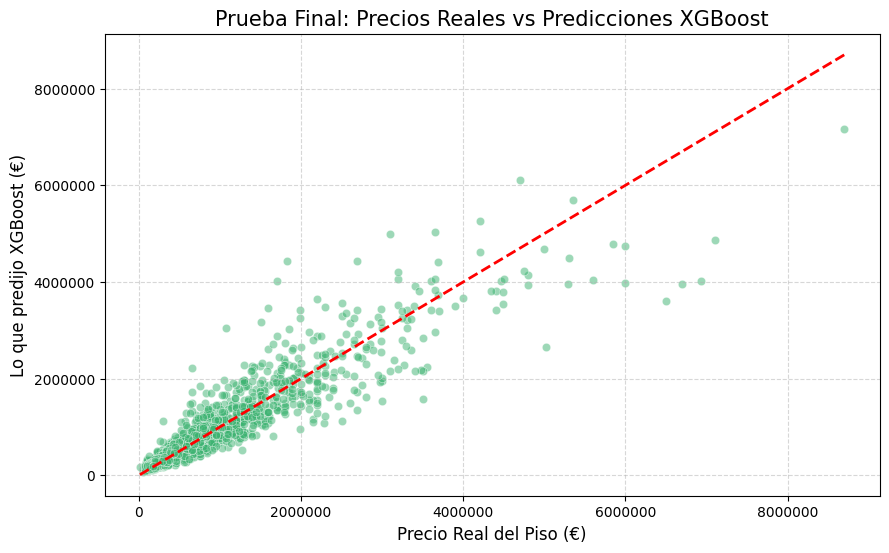

In [196]:
# 1. CREAMOS LA TABLA DEL CARA A CARA
comparacion = pd.DataFrame({
    'Precio Real': y_test,
    'Predicción XGBoost': predicciones_xgb # Usamos la variable exacta de tu modelo
})

# Calculamos por cuánto dinero ha fallado y el porcentaje de error
comparacion['Fallo (€)'] = abs(comparacion['Precio Real'] - comparacion['Predicción XGBoost'])
comparacion['Error (%)'] = (comparacion['Fallo (€)'] / comparacion['Precio Real']) * 100

# Mostramos una muestra aleatoria de 10 pisos
print("--- EL CARA A CARA CON TODAS LAS VARIABLES (MUESTRA DE 10 PISOS) ---")
print(comparacion.sample(10, random_state=42).map(lambda x: f"{x:,.0f}").to_string())

# 2. DIBUJAMOS EL GRÁFICO DE LA VERDAD
plt.figure(figsize=(10, 6))

# Puntos verdes: Las predicciones de tu modelo XGBoost completo
sns.scatterplot(x=y_test, y=predicciones_xgb, alpha=0.5, color='mediumseagreen')

# Línea roja: La línea de la perfección (acierto exacto)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)

plt.title('Prueba Final: Precios Reales vs Predicciones XGBoost', fontsize=15)
plt.xlabel('Precio Real del Piso (€)', fontsize=12)
plt.ylabel('Lo que predijo XGBoost (€)', fontsize=12)

# Formateamos los ejes para quitar la notación científica (e+05)
plt.ticklabel_format(style='plain', axis='both')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# EXPORTAR MODELO IA 

In [197]:
import joblib
import os
from IPython.display import FileLink

# A. Nos aseguramos de que el modelo esté entrenado
# (Aquí uso el nombre 'modelo_xgb' que es el que tenías en tu código)
nombre_modelo = 'modelo_idealista_v1.joblib'

# B. Guardar el modelo en la carpeta de trabajo de Kaggle
joblib.dump(modelo_xgb, f'/kaggle/working/{nombre_modelo}')

# C. FORZAR DESCARGA: Esto crea un enlace azul para descargar directo
print("--- DESCARGA DIRECTA ---")
display(FileLink(nombre_modelo))

# D. Verificación de archivos
print("\n Archivos actualmente en la carpeta de salida:")
print(os.listdir('/kaggle/working/'))

--- DESCARGA DIRECTA ---


/kaggle/working/modelo_idealista_v1.joblib


 Archivos actualmente en la carpeta de salida:
['.virtual_documents', 'modelo_idealista_v1.joblib']
